In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split

# For handling class imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *

In [3]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")
df = basic_cleaning(df)

In [4]:
df = create_features(df)

In [5]:
df["High_Risk"] = np.where(
    df["Default_History_Count"] > 0,
    1,
    0
)

In [6]:
df["High_Risk"].value_counts()

High_Risk
0    906
1     94
Name: count, dtype: int64

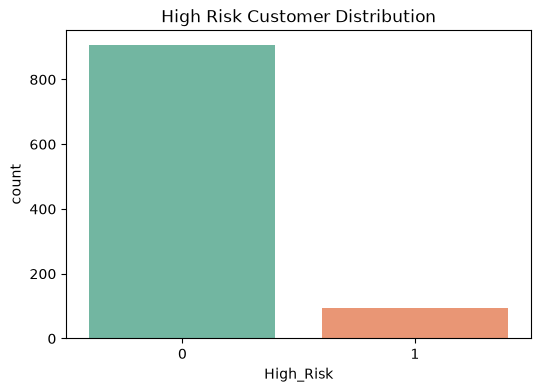

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="High_Risk",
    palette="Set2"
)

plt.title("High Risk Customer Distribution")

plt.show()

In [8]:
features = [
    "Default_History_Count",
    "Debt_to_Income_Ratio",
    "Existing_EMIs",
    "CIBIL_Score",
    "Employment_Length_Years",
    "Annual_Household_Income",
    "Loan_to_Annual_Income",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

target = "High_Risk"

In [9]:
X, y = select_features(
    df,
    features,
    target
)

In [10]:
num_features, cat_features = get_feature_types(X)

In [11]:
preprocessor = create_preprocessor(
    num_features,
    cat_features
)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print(y_train.value_counts())

High_Risk
0    725
1     75
Name: count, dtype: int64


In [14]:
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(
    X_train,
    y_train
)
print(y_train.value_counts())

High_Risk
0    725
1    725
Name: count, dtype: int64


In [15]:
from src.train import build_pipeline
lr_pipeline = build_pipeline(
    preprocessor,
    LogisticRegression(random_state=42)
)

In [16]:
lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Default_History_Count','Debt_to_Income_Ratio','Existing_EMIs',..., 'Total_Income','Loan_Income_Ratio','EMI_Income_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

In [17]:
lr_pred = predict(
    lr_pipeline,
    X_test
)

In [18]:
lr_results = evaluate_classification2(
    y_test,
    lr_pred,
    "Logistic Regression"
)
lr_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0


In [19]:
print_classification_report(
    y_test,
    lr_pred
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00        19

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



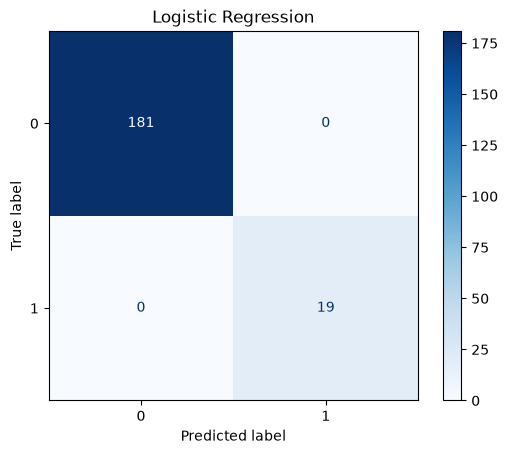

In [20]:
plot_confusion_matrix(
    y_test,
    lr_pred,
    "Logistic Regression"
)

In [21]:
rf_pipeline = build_pipeline(
    preprocessor,
    RandomForestClassifier(random_state=42)
)

In [22]:
rf_params = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,15],
    "classifier__min_samples_split":[2,5],
    "classifier__min_samples_leaf":[1,2]
}

In [23]:
grid_rf = perform_grid_search(
    pipeline=rf_pipeline,
    parameters=rf_params,
    X_train=X_train,
    y_train=y_train,
    scoring="recall"
)

In [24]:
grid_rf.best_params_

{'classifier__max_depth': 5,
 'classifier__min_samples_leaf': 1,
 'classifier__min_samples_split': 2,
 'classifier__n_estimators': 100}

In [25]:
best_rf = grid_rf.best_estimator_

rf_pred = predict(
    best_rf,
    X_test
)

In [26]:
rf_results = evaluate_classification2(
    y_test,
    rf_pred,
    "Random Forest"
)

rf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,1.0,1.0,1.0,1.0


In [27]:
print_classification_report(
    y_test,
    rf_pred
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       181
           1       1.00      1.00      1.00        19

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



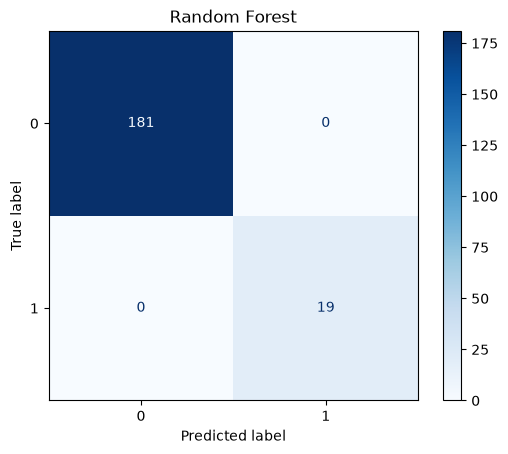

In [28]:
plot_confusion_matrix(
    y_test,
    rf_pred,
    "Random Forest"
)

In [29]:
gb_pipeline = build_pipeline(
    preprocessor,
    GradientBoostingClassifier(random_state=42)
)

In [30]:
gb_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Default_History_Count','Debt_to_Income_Ratio','Existing_EMIs',..., 'Total_Income','Loan_Income_Ratio','EMI_Income_Ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``

In [31]:
gb_pred = predict(
    gb_pipeline,
    X_test
)

In [32]:
gb_results = evaluate_classification2(
    y_test,
    gb_pred,
    "Gradient Boosting"
)

gb_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Gradient Boosting,1.0,1.0,1.0,1.0


In [33]:
comparison = pd.concat(
    [
        lr_results,
        rf_results,
        gb_results
    ],
    ignore_index=True
)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0


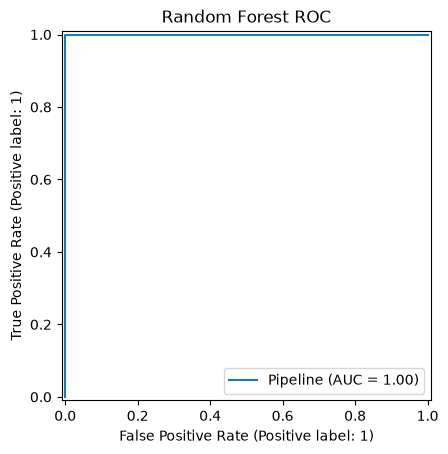

In [35]:
plot_roc_curve(

    best_rf,

    X_test,

    y_test,

    "Random Forest ROC"

)

In [36]:
feature_names = best_rf.named_steps[
    "preprocessor"
].get_feature_names_out()

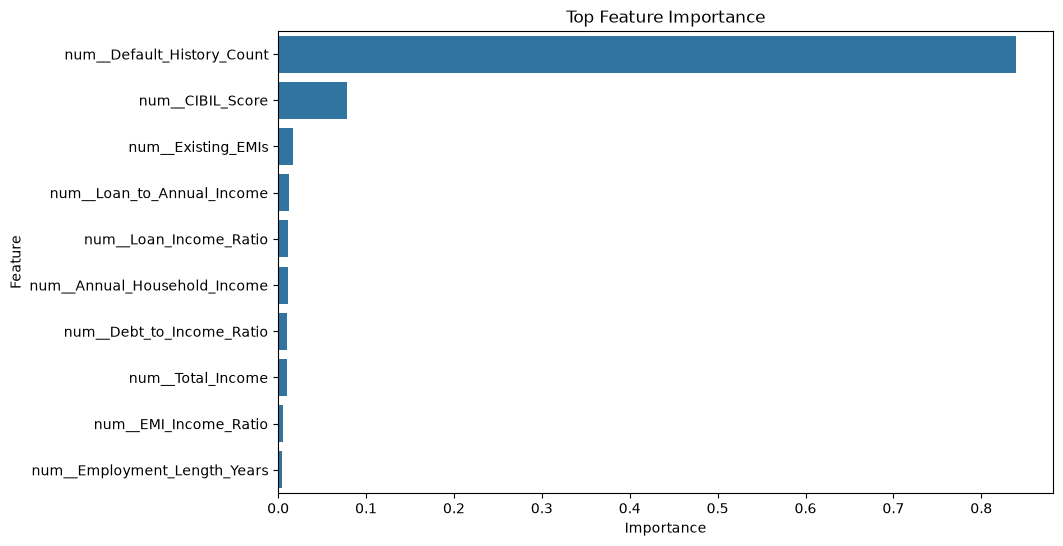

,Feature,Importance
0,num__Default_History_Count,0.839798
3,num__CIBIL_Score,0.078283
2,num__Existing_EMIs,0.016769
6,num__Loan_to_Annual_Income,0.012326
8,num__Loan_Income_Ratio,0.011636
5,num__Annual_Household_Income,0.011527
1,num__Debt_to_Income_Ratio,0.009911
7,num__Total_Income,0.009868
9,num__EMI_Income_Ratio,0.005296
4,num__Employment_Length_Years,0.004586


In [37]:
feature_importance = plot_feature_importance(

    best_rf,

    feature_names

)

feature_importance.head(10)

In [38]:
high_risk = df[df["High_Risk"] == 1]

high_risk.describe()

,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Age,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,...,Loan_to_Annual_Income,PIN_Code,Aadhaar_Synthetic,Phone_Number,Total_Income,EMI_Income_Ratio,Loan_Income_Ratio,Monthly_Savings,Asset_Loan_Ratio,High_Risk
count,94.000000,94.000000,94.000000,9.400000e+01,94.000000,94.0,94.000000,94.000000,9.400000e+01,94.000000,...,94.000000,94.000000,9.400000e+01,9.400000e+01,94.000000,94.000000,94.000000,94.000000,94.000000,94.0
mean,0.936170,45324.265957,7639.351064,1.860445e+06,134.553191,0.0,35.159574,603.446809,6.355634e+05,1.109223,...,11.483511,525648.425532,5.014887e+11,9.487867e+09,52963.617021,1.108917,137.772743,29680.223404,4.381963,1.0
std,0.948213,32268.800986,17845.546895,2.533698e+06,124.966543,0.0,8.758778,78.791083,4.840995e+05,2.426362,...,36.025123,291769.272089,2.974141e+11,2.751498e+08,40341.622816,2.425337,432.175236,23386.376182,5.917143,0.0
min,0.000000,1519.000000,0.000000,5.742700e+04,12.000000,0.0,18.000000,384.000000,1.822800e+04,0.000000,...,0.095000,1187.000000,7.418949e+09,9.002721e+09,1519.000000,0.000000,1.142644,0.000000,0.000000,1.0
25%,0.000000,14741.750000,0.000000,3.372358e+05,36.000000,0.0,29.000000,544.500000,1.967760e+05,0.000000,...,0.565250,268638.000000,2.620000e+11,9.285400e+09,16398.000000,0.000000,6.784540,8854.000000,0.529088,1.0
50%,1.000000,43912.000000,0.000000,6.954865e+05,60.000000,0.0,36.000000,611.000000,5.665860e+05,0.312500,...,1.673000,569631.500000,4.730000e+11,9.463270e+09,47215.500000,0.312133,20.075989,25990.500000,2.021038,1.0
75%,1.000000,69138.000000,3263.500000,1.744697e+06,240.000000,0.0,40.750000,662.750000,9.639930e+05,0.696500,...,6.016000,778805.000000,7.545000e+11,9.766767e+09,80332.750000,0.696321,72.175551,41948.500000,5.950194,1.0
max,3.000000,119153.000000,85053.000000,1.172295e+07,360.000000,0.0,64.000000,772.000000,1.929468e+06,13.925000,...,256.467000,991720.000000,9.830000e+11,9.983735e+09,160789.000000,13.915789,3076.573476,95573.000000,34.238159,1.0


In [39]:
high_risk["CIBIL_Score"].mean()

np.float64(603.4468085106383)

In [40]:
high_risk["Debt_to_Income_Ratio"].mean()

np.float64(1.1092234042553188)

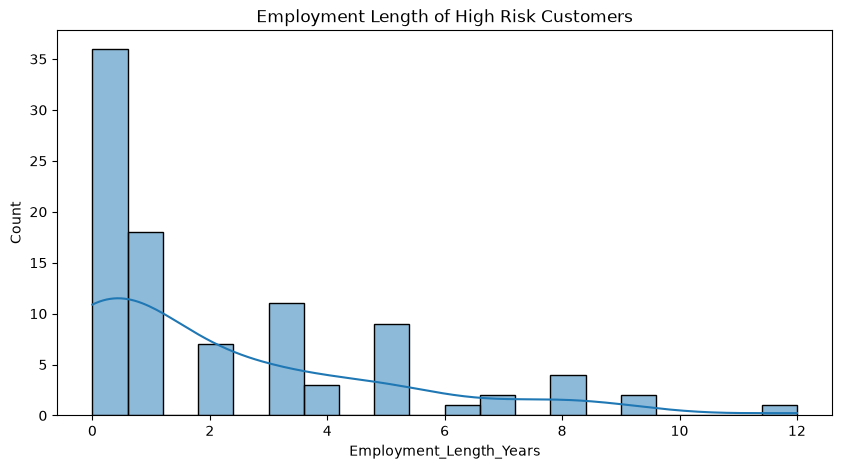

In [41]:
plt.figure(figsize=(10,5))

sns.histplot(

    high_risk["Employment_Length_Years"],

    bins=20,

    kde=True

)

plt.title("Employment Length of High Risk Customers")

plt.show()

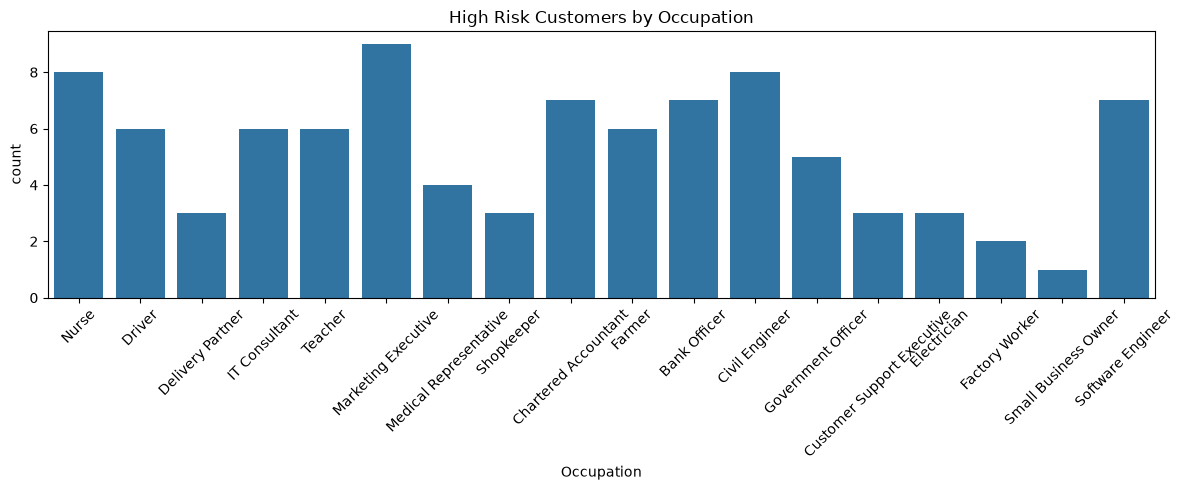

In [42]:
plt.figure(figsize=(12,5))

sns.countplot(

    data=high_risk,

    x="Occupation"

)

plt.xticks(rotation=45)

plt.title("High Risk Customers by Occupation")

plt.tight_layout()

plt.show()

In [43]:
joblib.dump(

    best_rf,

    "../models/risk_model.pkl"

)

print("Risk Model Saved Successfully")

Risk Model Saved Successfully
